In [ ]:
# 부록 1 - 설치
!pip -qq install openai pillow imageio imageio-ffmpeg numpy

In [ ]:
# 부록 2 - OpenAI API 키 불러오기
from google.colab import userdata
OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

In [ ]:
# 부록 3 - 라이브러리
from openai import OpenAI
from PIL import Image, ImageDraw
from io import BytesIO
import base64, os, math
import numpy as np
import imageio.v2 as imageio

client = OpenAI(api_key=OPENAI_API_KEY)

In [ ]:
# 부록 4 - 이미지 생성 함수
def generate_image(prompt, filename="scene.png", size="1024x1024", quality="medium"):
    result = client.images.generate(
        model="gpt-image-1",
        prompt=prompt,
        size=size,
        quality=quality,
        n=1
    )
    image_bytes = base64.b64decode(result.data[0].b64_json)
    img = Image.open(BytesIO(image_bytes)).convert("RGB")
    img.save(filename)
    return img

In [ ]:
# 부록 5 - 기존 실습에서 만든 4개 결과를 설명 문자열로 정리
# - 아래 변수들은 기존 노트북 흐름에 맞게 이미 존재한다고 가정:
#   describedresult, originalprompt, dataset[searchedidx]["prompt"]
# - 없으면 예시 문자열로 대체 가능

try:
    desc_a = "원본 이미지 기반 상상 동물"
    desc_b = describedresult[:400]
    desc_c = originalprompt[:300]
    desc_d = dataset[searchedidx]["prompt"][:300]
except:
    desc_a = "a: 귀엽고 환상적인 상상 동물"
    desc_b = "b: 털이 복슬복슬하고 밝은 표정의 상상 동물"
    desc_c = "c: 토끼, 고양이, 사자 느낌이 섞인 아기 동물"
    desc_d = "d: 르네상스풍 감성의 판타지 동물"

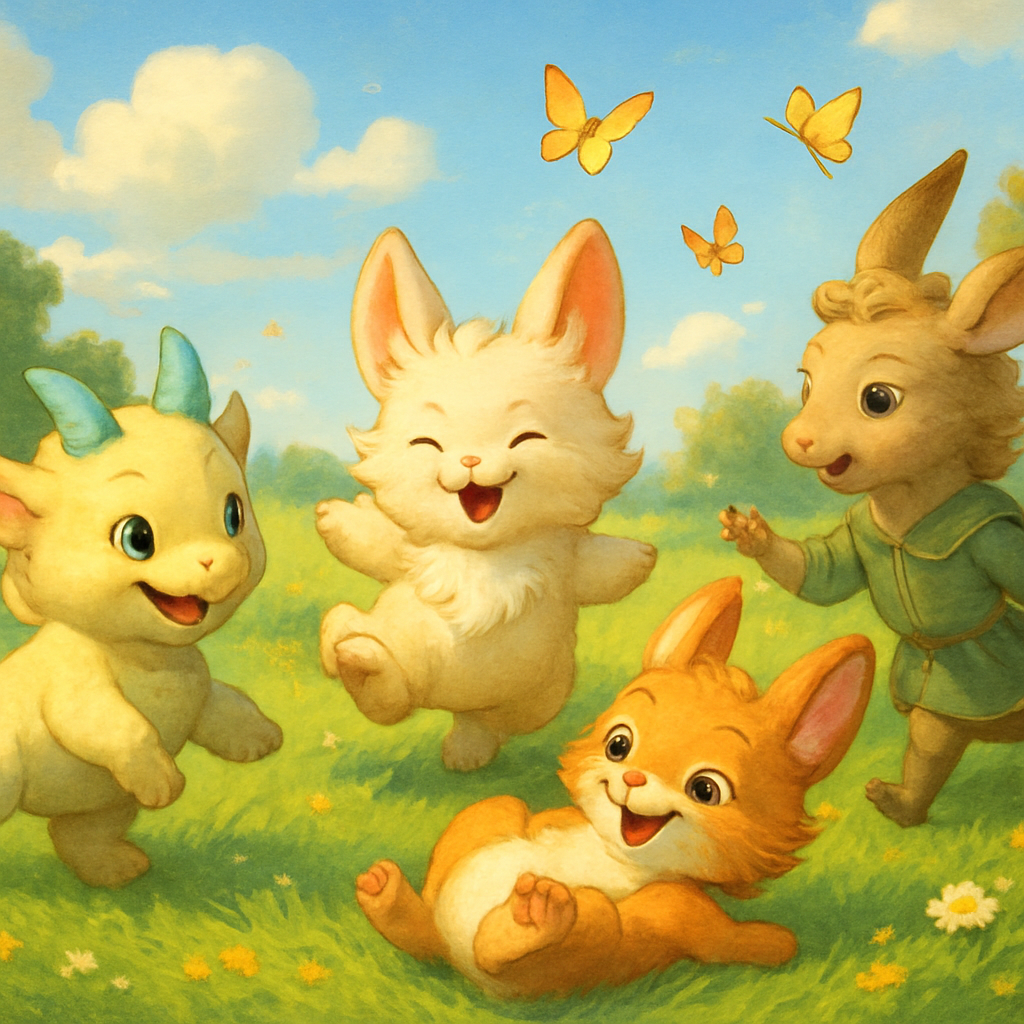

In [ ]:
# 부록 6 - 4마리 동물이 함께 노는 통합 장면 프롬프트 만들기
video_scene_prompt = f"""
Create a single cheerful fantasy scene for students.
Four different imaginary baby animals are playing together happily in a sunny meadow.
They should look like four distinct cute hybrid creatures inspired by these ideas:

1) {desc_a}
2) {desc_b}
3) {desc_c}
4) {desc_d}

Requirements:
- all four creatures must appear together in one image
- joyful mood, playful interaction, friendship
- bright colors, whimsical, safe for school
- one creature is running, one is jumping, one is rolling on the grass, one is chasing butterflies
- cinematic composition, storybook style, high detail
- no text, no watermark
"""

scene_img = generate_image(video_scene_prompt, filename="fantasy_animals_scene.png")
scene_img

In [ ]:
# 부록 7 - 이미지에 팬/줌 효과를 주어 짧은 영상 프레임 만들기
from PIL import Image

def make_ken_burns_frames(
    img,
    out_dir="video_frames",
    num_frames=72,      # 6초 @ 12fps
    out_size=(768, 768),
    zoom_start=1.00,
    zoom_end=1.12,
    pan_x=0.06,
    pan_y=0.04
):
    os.makedirs(out_dir, exist_ok=True)
    w, h = img.size
    out_w, out_h = out_size

    for i in range(num_frames):
        t = i / (num_frames - 1)
        zoom = zoom_start + (zoom_end - zoom_start) * t

        crop_w = int(w / zoom)
        crop_h = int(h / zoom)

        cx = w // 2 + int((t - 0.5) * pan_x * w)
        cy = h // 2 + int(math.sin(t * math.pi) * pan_y * h)

        left = max(0, min(w - crop_w, cx - crop_w // 2))
        top = max(0, min(h - crop_h, cy - crop_h // 2))
        right = left + crop_w
        bottom = top + crop_h

        frame = img.crop((left, top, right, bottom)).resize(out_size, Image.LANCZOS)

        # 하단에 간단한 제목 막대 추가(선택)
        draw = ImageDraw.Draw(frame)
        draw.rounded_rectangle((20, out_h - 80, out_w - 20, out_h - 20), radius=20, fill=(0,0,0,110))
        draw.text((40, out_h - 62), "Imaginary animals playing together", fill="white")

        frame.save(f"{out_dir}/frame_{i:03d}.png")

make_ken_burns_frames(scene_img)

In [ ]:
# 부록 8 - 프레임을 MP4로 저장
frames = []
frame_files = sorted([f"video_frames/{x}" for x in os.listdir("video_frames") if x.endswith(".png")])

for f in frame_files:
    frames.append(imageio.imread(f))

output_path = "imaginary_animals_short_video.mp4"
imageio.mimsave(output_path, frames, fps=12)

print(output_path)

imaginary_animals_short_video.mp4


In [ ]:
# 부록 9 - Colab에서 바로 재생
from IPython.display import Video
Video(output_path, embed=True)